# 1. Синтетические данные: волна, датчики и тор
Волна от колеблющегося источника проходит через среду, датчики её записывают. По записям строим фазовое пространство и проверяем, что траектория лежит на торе.

In [1]:
import sys, warnings
import numpy as np, matplotlib.pyplot as plt
import plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image
warnings.filterwarnings("ignore")
sys.path.insert(0, "../synthetic")
from wave import grid, medium, solve, exact
from scenarios import SCENARIOS, NU, START, WALL, simulate
from torus import pca, spectrum, with_delay
from figures import animation3d
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.titlesize": 11, "axes.spines.top": False, "axes.spines.right": False})
pio.renderers.default = "plotly_mimetype+notebook_connected"

## 1. Модель
$$u_{tt}=\frac{1}{n(r)^2}\,\Delta u+f(t)\,\delta(r-r_0),\qquad r\in[0,1]^d,\ d=1,2,3.$$
- $u$: отклонение среды от покоя.
- $n(r)$: показатель преломления; скорость волны $1/n$.
- $f$: источник в точке $r_0$.
- Граница поглощает волны (раздел 4).
- В сценарии «стоячая волна» при $x\ge0.8$ стоит отражающая стенка $u=0$.

## 2. Среды
Контраст $\alpha=0.3$, ширина $\ell=0.1$; $z$ обозначает последнюю координату.
- Однородная: $n=1$.
- Слоистая: $n=1,\ 1+\alpha,\ 1+\alpha/2$ в слоях $z<\tfrac13,\ \tfrac13\le z<\tfrac23,\ z\ge\tfrac23$.
- Линза с центром $r_c$ в середине области: $n=1+\alpha\,e^{-|r-r_c|^2/2\ell^2}$.
- Волновод: $n=1+\alpha\,e^{-(z-0.5)^2/2(\ell/2)^2}$.

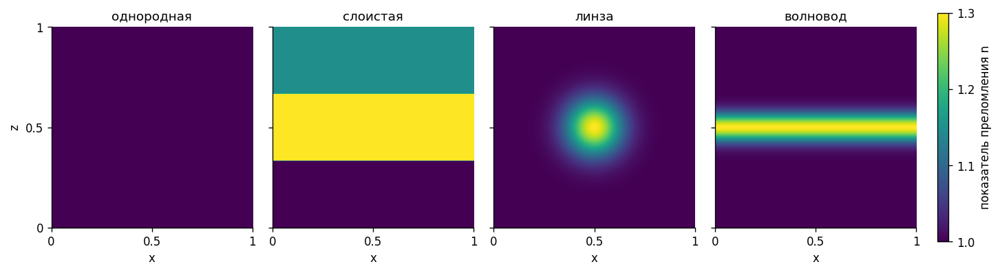

In [2]:
R, _ = grid(201, 2)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.4), sharey=True, layout="constrained")
for ax, kind in zip(axes, ["однородная", "слоистая", "линза", "волновод"]):
    im = ax.imshow(medium(kind, R).T, origin="lower", extent=(0, 1, 0, 1), cmap="viridis", vmin=1, vmax=1.3)
    ax.set(title=kind, xlabel="x", xticks=[0, 0.5, 1], xticklabels=["0", "0.5", "1"], yticks=[0, 0.5, 1], yticklabels=["0", "0.5", "1"])
axes[0].set_ylabel("z")
fig.get_layout_engine().set(wspace=0.05)
fig.colorbar(im, ax=axes, shrink=0.85, pad=0.02, ticks=[1, 1.1, 1.2, 1.3], label="показатель преломления n")
plt.show()

## 3. Источник и датчики
$$f=g',\qquad g(t)=\sin2\pi\nu_1t+0.7\sin2\pi\nu_2t,\qquad \nu_1=6\ \text{Гц},\ \nu_2=\sqrt2\,\nu_1.$$
- $\nu_2/\nu_1$ иррационально, поэтому $g$ не периодична.
- Из $f=g'$ следует: в однородной одномерной среде датчик записывает $g/2$ с запаздыванием (раздел 4).
- Источник включается плавно за первые 0.5 с.
- Источник стоит в точке $x=0.25$, остальные его координаты 0.5.
- Датчики образуют сетку на $[0.4,0.75]^d$: 8, $4\times4$ и $3\times3\times3$ датчиков в 1D, 2D, 3D.
- Шаг записи 0.01 с. Запись начинается после 1.5 с установления и длится 20, 10 и 6 с в 1D, 2D, 3D.
- Шум датчиков нормальный, его стандартное отклонение 2% от наибольшего модуля показаний.

## 4. Численное решение
Явная разностная схема на сетке из $L^d$ узлов с шагом $h=1/(L-1)$, где $L=801,\ 201,\ 101$ в 1D, 2D, 3D. Поле в момент $t_k=k\,\Delta t$ обозначено $u^k$:
$$\frac{u^{k+1}-2u^k+u^{k-1}}{\Delta t^2}+\sigma\,\frac{u^{k+1}-u^{k-1}}{2\Delta t}=c^2\,\Delta_hu^k+f(t_k)\,\delta_h,\qquad c=1/n.$$
- Разностный лапласиан с ортами осей $e_a$: $\Delta_hu(r)=h^{-2}\sum_a\bigl(u(r+he_a)-2u(r)+u(r-he_a)\bigr)$.
- $\delta_h$: дискретный аналог $\delta(r-r_0)$.
- Граница: $u_t+c\,\partial_\perp u=0$ по внешней нормали.
- В 2D и 3D у края ещё слой ширины 0.2, где волна гасится трением $\sigma u_t$; $\sigma$ растёт к краю, вне слоя $\sigma=0$. В 2D отражения от края меняют записи датчиков на величину от 1 до 3%.
- Датчик записывает поле в ближайшем к нему узле.

### Проверка на точном решении
**Задача.** Однородная среда без границ ($n=1$), в начале покой, в точке $r=0$ источник $s(t)$, $s=0$ при $t\le0$:
$$u_{tt}=\Delta u+s(t)\,\delta(r).$$
Нужно поле на расстоянии $\rho$ от источника.

**Решение.**
- $d=3$. Ищем сферическую волну $u=F(t-\rho)/\rho$.
  - Вне нуля это решение: $\rho u$ решает одномерное уравнение.
  - В нуле $\Delta(1/\rho)=-4\pi\delta(r)$, поэтому $u_{tt}-\Delta u=4\pi F(t)\,\delta(r)$, и $F=s/4\pi$:
$$u=\frac{s(t-\rho)}{4\pi\rho}.$$
- $d=1$. Ищем две волны, бегущие от источника: $u=F(t-|x|)$.
  - Вне нуля это решение: $u_{tt}=u_{xx}=F''$.
  - В нуле $u_x$ скачком меняется с $+F'$ на $-F'$, отсюда $u_{tt}-u_{xx}=2F'(t)\,\delta(x)$, и $F'=s/2$:
$$u=\frac12\int_0^{t-\rho}s(t')\,dt'.$$
- $d=2$. Точечный источник на плоскости $(x,z)$ равносилен нити источников в пространстве, перпендикулярной плоскости; $w$ обозначает координату вдоль нити. Складываем решения $d=3$ вдоль нити, $R=\sqrt{\rho^2+w^2}$, затем заменяем $t'=t-R$:
$$u=\int_{-\infty}^{\infty}\frac{s(t-R)}{4\pi R}\,dw=\frac1{2\pi}\int_0^{t-\rho}\frac{s(t')\,dt'}{\sqrt{(t-t')^2-\rho^2}}.$$

**Проверка.** Решаем ту же задачу схемой из раздела 4: импульс длительностью около 0.1 с (в 3D 0.2 с) в центре области, датчик на расстоянии 0.2, счёт до прихода отражений. Считаем на трёх сетках, каждая вдвое мельче предыдущей: у схемы второго порядка ошибка должна падать в 4 раза.

In [3]:
def check(d, grids, f0, t0, t_end):
    def s(t):
        a = (np.pi * f0 * (t - t0)) ** 2
        return (1 - 2 * a) * np.exp(-a)

    errors = []
    for N in grids:
        t, Y, _ = solve(np.ones((N,) * d), [(np.full(d, 0.5), s)], [np.array([0.7] + [0.5] * (d - 1))], t_end, dt_out=0.002, width=0.01)
        u = exact(0.2, t, s, d)
        errors.append(np.linalg.norm(Y[0] - u) / np.linalg.norm(u))
    ratios = ", ".join(f"{a / b:.1f}" for a, b in zip(errors, errors[1:]))
    print(f"{d}D: ошибка {', '.join(f'{e:.3f}' for e in errors)} на сетках {grids}; уменьшение в {ratios} раза")

check(1, [201, 401, 801], 10, 0.15, 0.6)
check(2, [101, 201, 401], 10, 0.15, 0.6)
check(3, [41, 81, 161], 5, 0.3, 0.7)

1D: ошибка 0.059, 0.014, 0.004 на сетках [201, 401, 801]; уменьшение в 4.1, 4.0 раза


2D: ошибка 0.379, 0.089, 0.021 на сетках [101, 201, 401]; уменьшение в 4.3, 4.2 раза


3D: ошибка 0.398, 0.086, 0.021 на сетках [41, 81, 161]; уменьшение в 4.6, 4.2 раза


## 5. Сценарии
- 1D: бегущая волна; стоячая волна (стенка); встречные волны ($\nu_2$ излучается из $x=0.8$); слоистая среда; шум источника.
- 2D: однородная, слоистая, линза, волновод.
- 3D: однородная, линза.
- Шум источника: к каждому слагаемому $g$ добавлен случайный сигнал в полосе от 0.5 до 20 Гц со стандартным отклонением 30% амплитуды слагаемого.

In [4]:
rng = np.random.default_rng(0)
data = {}
for name, sc in SCENARIOS.items():
    run = simulate(sc)
    run["noisy"] = run["Y"] + 0.02 * np.abs(run["Y"]).max() * rng.standard_normal(run["Y"].shape)
    data[name] = run

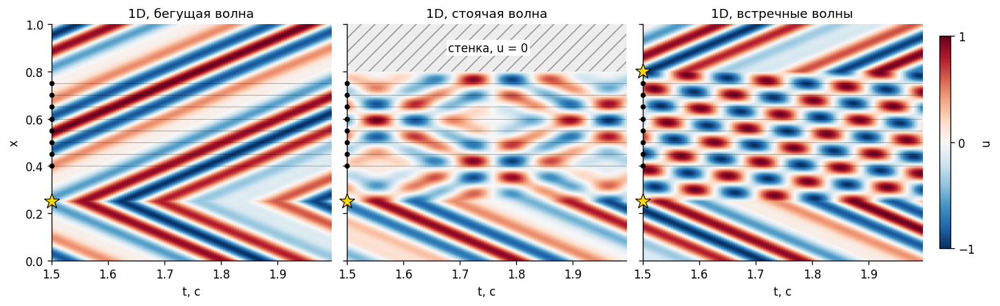

In [5]:
times = np.arange(START, START + 0.5, 0.005)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, layout="constrained")
for ax, name in zip(axes, ["1D, бегущая волна", "1D, стоячая волна", "1D, встречные волны"]):
    run = simulate(SCENARIOS[name], snap_times=times)
    field = np.array([run["snaps"][k] for k in times])
    im = ax.imshow(field.T / np.abs(field).max(), origin="lower", aspect="auto", extent=(times[0], times[-1], 0, 1), cmap="RdBu_r", vmin=-1, vmax=1)
    x, x0 = run["sensors"][:, 0], run["sources"][:, 0]
    ax.hlines(x, times[0], times[-1], color="k", lw=0.5, alpha=0.35)
    ax.plot(np.full(len(x), times[0]), x, "k.", ms=7, clip_on=False, zorder=3)
    ax.plot(np.full(len(x0), times[0]), x0, "*", color="gold", ms=14, mec="k", mew=0.7, clip_on=False, zorder=3)
    ax.set(title=name, xlabel="t, с")
axes[1].axhspan(WALL, 1, fc="0.93", ec="0.6", hatch="//", lw=0)
axes[1].text(times[len(times) // 2], (WALL + 1) / 2, "стенка, u = 0", ha="center", va="center", bbox=dict(fc="w", ec="none", pad=1.5))
axes[0].set_ylabel("x")
fig.colorbar(im, ax=axes, shrink=0.9, pad=0.02, ticks=[-1, 0, 1], label="u")
plt.show()

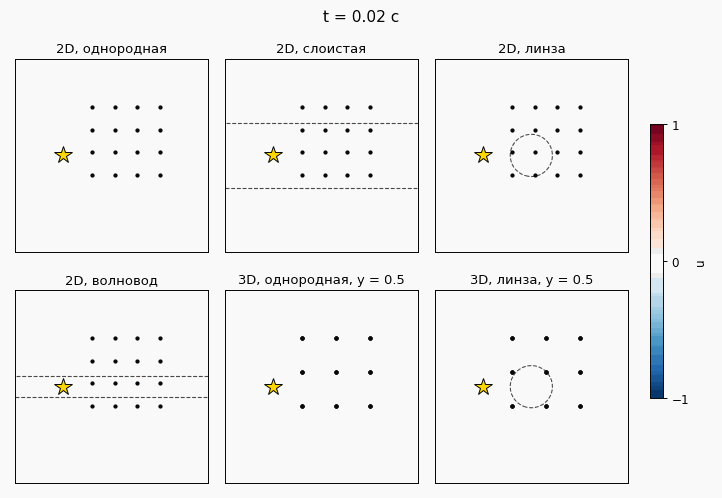

In [6]:
times = np.round(np.arange(0.02, START + 0.001, 0.02), 2)
cut = lambda a: a if a.ndim == 2 else a[:, a.shape[1] // 2]
fig, axes = plt.subplots(2, 3, figsize=(8.4, 5.8))
fig.subplots_adjust(left=0.02, right=0.87, bottom=0.03, top=0.88, wspace=0.08, hspace=0.2)
panels = []
for ax, name in zip(axes.flat, [s for s in SCENARIOS if not s.startswith("1D")]):
    run = simulate(SCENARIOS[name], snap_times=times, t_end=START)
    frames, n = [cut(run["snaps"][k]) for k in times], cut(run["n"])
    v = np.abs(frames[-1][int(0.4 * len(n)):]).max()
    frames = [f / v for f in frames]
    im = ax.imshow(frames[0].T, origin="lower", extent=(0, 1, 0, 1), cmap="RdBu_r", vmin=-1, vmax=1)
    if np.ptp(n) > 0:
        axis = np.linspace(0, 1, len(n))
        ax.contour(axis, axis, n.T, levels=[n.min() + 0.55 * np.ptp(n)], colors="k", linewidths=0.9, linestyles="--", alpha=0.7)
    ax.plot(run["sensors"][:, 0], run["sensors"][:, -1], "k.", ms=5)
    ax.plot(run["sources"][:, 0], run["sources"][:, -1], "*", color="gold", ms=15, mec="k", mew=0.8)
    ax.set(title=name + (", y = 0.5" if name.startswith("3D") else ""), xticks=[], yticks=[])
    ax.spines[["top", "right"]].set_visible(True)
    panels.append((im, frames))
fig.colorbar(im, cax=fig.add_axes((0.9, 0.2, 0.018, 0.55)), ticks=[-1, 0, 1], label="u")
title = fig.suptitle("", fontsize=13)

def update(k):
    for im, frames in panels:
        im.set_data(frames[k].T)
    title.set_text(f"t = {times[k]:.2f} с")

FuncAnimation(fig, update, frames=len(times)).save("propagation.gif", writer=PillowWriter(fps=12), dpi=86)
plt.close(fig)
Image(filename="propagation.gif")

In [7]:
animation3d().show(renderer="plotly_mimetype")

## 6. Фазовое пространство и тор
**Точка** фазового пространства: вектор $X(t)\in\mathbb R^{2N}$ из показаний $y_1,\dots,y_N$ датчиков в моменты $t$ и $t-\tau$, $\tau=0.04$ с (задержки Такенса). Со временем точка описывает траекторию.

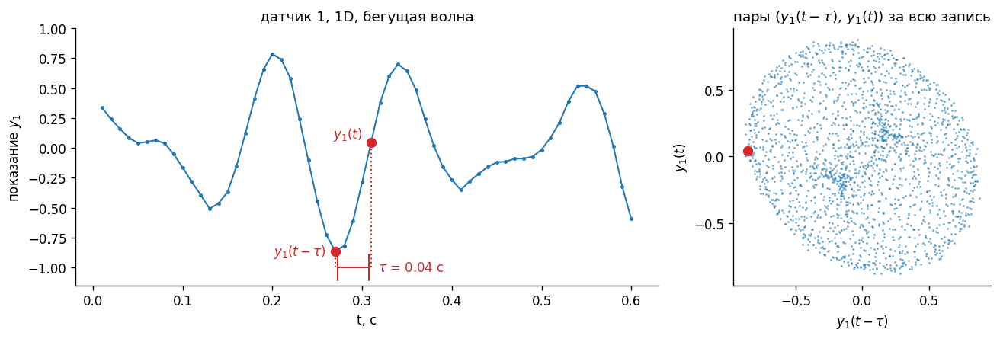

In [8]:
lag = round(1 / (4 * NU[0] * 0.01))
run = data["1D, бегущая волна"]
t, x, k = run["t"], run["noisy"][0], 30
pair = [k - lag, k]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [2, 1]}, layout="constrained")
ax[0].plot(t[:60], x[:60], ".-", color="C0", lw=1.2, ms=4)
ax[0].vlines(t[pair], -1, x[pair], color="C3", ls=":", lw=1.2)
ax[0].plot(t[pair], x[pair], "o", color="C3", ms=7)
ax[0].annotate("", xy=(t[k], -1), xytext=(t[k - lag], -1), arrowprops=dict(arrowstyle="|-|", color="C3", lw=1.2))
ax[0].text(t[k] + 0.008, -1, rf"$\tau$ = {t[k] - t[k - lag]:.2f} с", va="center", color="C3")
ax[0].text(t[k - lag] - 0.01, x[k - lag], r"$y_1(t-\tau)$", ha="right", va="center", color="C3")
ax[0].text(t[k] - 0.01, x[k], r"$y_1(t)$", ha="right", va="bottom", color="C3")
ax[0].set(xlabel="t, с", ylabel="показание $y_1$", ylim=(-1.15, 1), title="датчик 1, 1D, бегущая волна")
ax[1].plot(x[:-lag], x[lag:], ".", ms=1.5, color="C0", alpha=0.5)
ax[1].plot(x[k - lag], x[k], "o", color="C3", ms=7)
ax[1].set(xlabel=r"$y_1(t-\tau)$", ylabel="$y_1(t)$", aspect="equal", xticks=[-0.5, 0, 0.5], yticks=[-0.5, 0, 0.5], title=r"пары $(y_1(t-\tau),\,y_1(t))$ за всю запись")
plt.show()

### Тор
После установления датчик $i$ записывает сумму двух колебаний:
$$y_i(t)=A_i\cos(\theta_1+\varphi_i)+B_i\cos(\theta_2+\psi_i),\qquad \theta_j=2\pi\nu_jt.$$
Раскрыв косинусы, получаем: все $2N$ координат точки линейны по $p(\theta)=(\cos\theta_1,\sin\theta_1,\cos\theta_2,\sin\theta_2)^{\mathsf T}$, а задержка лишь сдвигает фазы, $\varphi_i'=\varphi_i-2\pi\nu_1\tau$, $\psi_i'=\psi_i-2\pi\nu_2\tau$:
$$X(t)=\begin{pmatrix}y_1(t)\\ \vdots\\ y_N(t)\\ y_1(t-\tau)\\ \vdots\\ y_N(t-\tau)\end{pmatrix}=H\,p(\theta),\qquad
H=\begin{pmatrix}
A_1\cos\varphi_1 & -A_1\sin\varphi_1 & B_1\cos\psi_1 & -B_1\sin\psi_1\\
\vdots & \vdots & \vdots & \vdots\\
A_N\cos\varphi_N & -A_N\sin\varphi_N & B_N\cos\psi_N & -B_N\sin\psi_N\\
A_1\cos\varphi_1' & -A_1\sin\varphi_1' & B_1\cos\psi_1' & -B_1\sin\psi_1'\\
\vdots & \vdots & \vdots & \vdots\\
A_N\cos\varphi_N' & -A_N\sin\varphi_N' & B_N\cos\psi_N' & -B_N\sin\psi_N'
\end{pmatrix}.$$

Пара фаз $\theta=(\theta_1,\theta_2)$ задаёт точку тора $\mathbb T^2$. По теореме Кронекера кривая $\theta(t)$ проходит сколь угодно близко к каждой точке тора. За период первого колебания фаза $\theta_2$ сдвигается на $\nu_2/\nu_1=\sqrt2$ оборота, то есть на целый оборот и ещё $\sqrt2-1\approx0.41$ оборота. Отношение иррационально, поэтому положения $\theta_2$ в начале каждого периода не повторяются и плотно покрывают окружность.

Отсчёты с шагом 0.01 с лежат на 50 окружностях тора с постоянной $\theta_1$, так как $\nu_1\cdot0.01=3/50$.

### Утверждение
**Самопересечение**: две пары фаз $\theta\ne\theta'$ с $X(\theta)=X(\theta')$. По такой точке состояние не восстановить.

**Утверждение.** $X(\theta)=H\,p(\theta)$ не имеет самопересечений тогда и только тогда, когда $\operatorname{rank}H=4$. В любых трёх линейных координатах самопересечения есть.

*Доказательство.*
1. Запишем $(\cos\theta_j,\sin\theta_j)$ как $e^{\mathrm i\theta_j}$. Тогда $p(\theta)-p(\theta')=(\zeta_1,\zeta_2)$ с хордами единичной окружности $\zeta_j=e^{\mathrm i\theta_j}-e^{\mathrm i\theta_j'}$. Хорда может иметь любое направление и любую длину до 2, а $\zeta_1$ и $\zeta_2$ выбираются независимо друг от друга, поэтому разности $p(\theta)-p(\theta')$ заполняют окрестность нуля в $\mathbb R^4$.
2. Если $\operatorname{rank}H<4$, в $\ker H$ есть сколь угодно короткие ненулевые векторы. По шагу 1 один из них равен $p(\theta)-p(\theta')$ с $\theta\ne\theta'$, то есть $X(\theta)=X(\theta')$.
3. Если $\operatorname{rank}H=4$, из $H\,p(\theta)=H\,p(\theta')$ следует $p(\theta)=p(\theta')$, то есть $\theta=\theta'$.
4. Три линейные координаты имеют вид $QX+b$, где $Q\in\mathbb R^{3\times2N}$, $b\in\mathbb R^3$. Так как $\operatorname{rank}QH\le3$, по шагу 2 с $QH$ вместо $H$ самопересечения есть. $\square$

### Проверка на данных
Точки $X(t)=H\,p(\theta)$ лежат в подпространстве размерности $\operatorname{rank}H$. Поэтому у облака точек ровно $\operatorname{rank}H$ заметных сингулярных чисел, остальные на уровне шума датчиков. По утверждению тор без самопересечений означает $\operatorname{rank}H=4$: должно быть 4 заметных числа. Ниже слева проекция траектории на три главные оси облака: сингулярные векторы с тремя наибольшими сингулярными числами после вычитания среднего; цвет показывает четвёртую ось. Справа сингулярные числа, делённые на наибольшее.

In [9]:
run = data["2D, линза"]
X = with_delay(run["noisy"], lag)
P, s = pca(X), spectrum(X)[:12]
T = 600
c = P[:T, 3]
k = np.arange(1, len(s) + 1)
fig = make_subplots(1, 2, specs=[[{"type": "scene"}, {"type": "xy"}]], column_widths=[0.6, 0.4], horizontal_spacing=0.15,
                    subplot_titles=("2D, линза: три главные оси", "сингулярные числа"))
fig.add_trace(go.Scatter3d(x=P[:T, 0], y=P[:T, 1], z=P[:T, 2], mode="lines", customdata=np.c_[run["t"][lag:T + lag], c],
                           line=dict(width=3, color=c, colorscale="Plasma", colorbar=dict(title="ось 4", x=0.44, len=0.6, thickness=12, tickvals=[c.min(), 0, c.max()], ticktext=["−", "0", "+"])),
                           hovertemplate="t = %{customdata[0]:.2f} с<br>ось 1: %{x:.2f}<br>ось 2: %{y:.2f}<br>ось 3: %{z:.2f}<br>ось 4: %{customdata[1]:.2f}<extra></extra>"), 1, 1)
fig.add_trace(go.Scatter(x=k, y=s, mode="lines+markers", line_color="#1f77b4", marker_size=8, hovertemplate="номер %{x}: %{y:.3f}<extra></extra>"), 1, 2)
hide = dict(showticklabels=False, showspikes=False)
fig.update_scenes(xaxis=dict(title="ось 1", **hide), yaxis=dict(title="ось 2", **hide), zaxis=dict(title="ось 3", **hide), aspectmode="data", camera_eye=dict(x=0.6, y=0, z=2))
fig.update_xaxes(title="номер", dtick=1, row=1, col=2)
fig.update_yaxes(title="доля наибольшего", type="log", row=1, col=2)
fig.update_layout(template="plotly_white", height=480, showlegend=False, margin=dict(l=10, r=20, t=50, b=40))
fig.show()

In [10]:
for name, run in data.items():
    print(f"{name:22s}", " ".join(f"{v:.3f}" for v in spectrum(with_delay(run["noisy"], lag))[:6]))

1D, бегущая волна      1.000 0.994 0.737 0.669 0.018 0.018
1D, стоячая волна      1.000 0.938 0.807 0.446 0.023 0.023
1D, встречные волны    1.000 0.995 0.720 0.664 0.018 0.018
1D, слоистая среда     1.000 0.964 0.711 0.528 0.018 0.018
1D, шум источника      1.000 0.995 0.742 0.681 0.238 0.235
2D, однородная         1.000 0.973 0.787 0.737 0.020 0.020
2D, слоистая           1.000 0.974 0.672 0.635 0.018 0.018
2D, линза              1.000 0.941 0.771 0.634 0.018 0.018
2D, волновод           1.000 0.895 0.690 0.684 0.025 0.024
3D, однородная         1.000 0.919 0.758 0.669 0.022 0.021
3D, линза              1.000 0.922 0.766 0.629 0.020 0.020


## Итог
- Численное решение сходится к точному со вторым порядком.
- Во всех 10 сценариях без шума источника у облака точек 4 заметных сингулярных числа (от 0.45 до 1), а следующие не больше 0.025. Значит, $\operatorname{rank}H=4$, и по утверждению самопересечений нет.
- Случайный сигнал источника добавляет заметные числа (пятое 0.24): тор размывается.